# RAG Pipeline with Chained Prompt Processing - Healthcare
Authors:  
 - [Lior Gazit](https://www.linkedin.com/in/liorgazit).  
 - [Meysam Ghaffari](https://www.linkedin.com/in/meysam-ghaffari-ph-d-a2553088/).  

This Colab notebook is referenced in our book's Github repo:   
https://github.com/PacktPublishing/Mastering-NLP-From-Foundations-to-Agents-Second-Edition   
<a target="_blank" href="https://colab.research.google.com/github/PacktPublishing/Mastering-NLP-From-Foundations-to-Agents-Second-Edition/blob/main/Chapter10_notebooks/Ch10_in_house_chatbot_healthcare.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


This notebook is taught and reviewed in our book:  
**[Mastering NLP from Foundations to Agents](https://www.amazon.com/Mastering-NLP-Foundations-Agents-Automation/dp/1806106132)**  
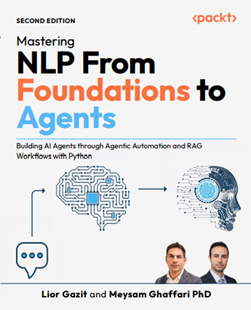



**The purpose of this notebook:**  
Building an in-house healthcare chatbot using a Retrieval-Augmented Generation (RAG) workflow over mocked physician records.  
This notebook demonstrates an end-to-end pipeline for loading clinical notes, splitting them into chunks, embedding and indexing them in FAISS, retrieving relevant context, and generating grounded responses with LLM prompt chaining.  

The pipeline consists of:  
1. Installing dependencies  
1. Imports and API configuration  
1. Loading mocked physician notes  
1. Chunking and preprocessing documents  
1. Building embeddings and a FAISS vector database  
1. Retrieving the top relevant chunks  
1. Chaining prompts for context-aware answering  
1. Running and evaluating chatbot responses  

Running LLMs locally for free: This code leverages [`LLMPop`](https://pypi.org/project/llmpop/) that is dedicated to spinning up local or remote LLMs in a unified and modular syntax.  

**Requirements:**  
* When running in Colab, use this runtime notebook setting: `Python 3, T4 GPU`  
* Set an OpenAI API key only if you choose an OpenAI model (optional in this notebook).  

>*```Disclaimer: The content and ideas presented in this notebook are solely those of the authors and do not represent the views or intellectual property of the authors' employers.```*

Installing:

In [1]:
%pip -q install llmpop
%pip -q install sentence-transformers faiss-cpu langchain langchain_core -U langchain-community

from llmpop import install_ollama_deps
install_ollama_deps()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.2/502.2 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
Installing system dependencies for Ollama: zstd, pciutils


**Imports:**

In [2]:
import os
import requests
import openai
from llmpop import init_llm
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.faiss import DistanceStrategy
import numpy as np
from collections import OrderedDict

# In Colab, use getpass to securely prompt for your API key
from getpass import getpass

Define OpenAI's API key:  
**If you wish to use OpenAI's API (optional for this notebook) paste it as a string:**  

In [3]:
os.environ["OPENAI_API_KEY"] = getpass("Paste your OpenAI API key: ")

Paste your OpenAI API key: ··········


Code Settings:

In [4]:
# In the data file we're using, this short string is a dilimiter between different clinical reports:
split_text_by = '"Title: Mocked up record'
chunk_size = 2000
chunk_overlap = 0
top_k = 2

### Load Text File With Mocked Physician Notes
These files hold the information we are looking to tap into.  
In this particular example, we concatenated all the mocked reports to a single .CSV table, just so to make the loading short and simple.  

In [5]:
text_file_path = "mocked_up_physician_records.csv"
url = "https://raw.githubusercontent.com/PacktPublishing/Mastering-NLP-from-Foundations-to-LLMs/main/Chapter8_notebooks/" + text_file_path
res = requests.get(url)
with open(text_file_path, "w") as f:
  f.write(res.text)

Load the text content of the file:

In [6]:
# Document Loader
text_loader = TextLoader(text_file_path)
documents = text_loader.load()

Showcasing an example of accessing the raw text:

In [7]:
print(documents[0].page_content[0:200])

"Title: Mocked up record
Physician Name: Dr. ABC
Date: June 25, 2099
Patient ID: 987654321
Chief Complaint: Abdominal pain

History of Present Illness:
The patient, Mr. John Anderson, a 42-year-old ma


## Embedding and indexing

### Process the data so to be prepared for embedding

In [8]:
# Text Splitter
text_splitter = CharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap, separator=split_text_by)
split_docs = text_splitter.split_documents(documents)

In [9]:
len(split_docs)

4

In [10]:
print(split_docs[0].page_content)

Physician Name: Dr. ABC
Date: June 25, 2099
Patient ID: 987654321
Chief Complaint: Abdominal pain

History of Present Illness:
The patient, Mr. John Anderson, a 42-year-old male, presents today with a chief complaint of abdominal pain. He is married and resides with his wife and two children. Mr. Anderson recently returned from a business trip to Europe about two weeks ago. He denies any respiratory symptoms or exposure to sick individuals during his travel.

During the evaluation, Mr. Anderson revealed a pertinent family history of cardiovascular disease, with his father having suffered a myocardial infarction in his 60s. He also reports that his maternal grandmother had type 2 diabetes. Mr. Anderson denies any personal history of chronic illnesses, surgeries, or hospitalizations.

Regarding his chief complaint, Mr. Anderson describes the abdominal pain as a dull, intermittent ache located in the lower right quadrant. He rates the pain as 5 out of 10 in severity. The pain is exacerbat

### Creating the embeddings that would be stored in the vector database
Using an open source model from Hugging Face.

In [11]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2", encode_kwargs={'normalize_embeddings': True})

/tmp/ipython-input-274/3252465728.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2", encode_kwargs={'normalize_embeddings': True})
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional 

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Create the vector database

For a vector database we picked FAISS (Facebook AI Similarity Search):  
More about it here: https://python.langchain.com/en/latest/modules/indexes/vectorstores.html

In [12]:
vector_db = FAISS.from_documents(split_docs, embeddings, distance_strategy=DistanceStrategy.MAX_INNER_PRODUCT)

A function that takes the structure of retrieved documents and formats it as a string:

In [13]:
def format_documents(doc_list):
    formatted_entries = []
    for doc, _ in doc_list:
        entry = (
            f"vector DB identifier='{doc.id}'\n"
            f"source: '{doc.metadata.get('source', '')}'\n"
            f"page_content='{doc.page_content}'\n"
            "\nEnd of case."
            "\n---\n"
        )
        formatted_entries.append(entry)
    return "\n".join(formatted_entries)

## Experiment with similarity search based on our "inhouse" documents
Here we only leverage vector database based on vector distance.  
We do not include any model for inferring similarity or relevance.

**Question: Are there any pregnant patients who are due to deliver in August?**  

In [14]:
query1 = "Are there any pregnant patients who are due to deliver in August?"
print("The Question: ", query1)

docs = vector_db.similarity_search_with_score(query1, k=top_k)
print("\n\nThe top two retrieved documents for context:")
print("\n## Top retrieved document:\n", str(docs[0][0].page_content))
print("\n## Secondary retrieved document:\n", str(docs[1][0].page_content))

The Question:  Are there any pregnant patients who are due to deliver in August?


The top two retrieved documents for context:

## Top retrieved document:
 Physician Name: Dr. ABC
Date: July 10, 2099
Patient ID: 246813579
Chief Complaint: Pregnancy Follow-up

History of Present Illness:
The patient, Mrs. Emily Adams, a 30-year-old female, presents today for a routine pregnancy follow-up. She is currently 32 weeks pregnant, with a due date of August 27th, 2099. Mrs. Adams is married and lives with her husband.

During the evaluation, Mrs. Adams reveals a family history of gestational diabetes, with her mother having developed the condition during her own pregnancies. She mentions no personal history of significant medical conditions, surgeries, or complications in previous pregnancies.

Regarding her chief complaint, Mrs. Adams reports typical discomforts associated with the third trimester of pregnancy, including backache, frequent urination, and occasional heartburn. She denies any v

**Question #2: Are there any pregnant patients who are due to deliver in September?**  
This is an example the answer to the question doesn't exist in the data.  
There are no pregnant patients who are due to deliber in September.  
The similarity search surfaces the cases which are most similar to what the question is asking about, but it would require further judgement to provide a final answer.

In [15]:
query2 = "Are there any pregnant patients who are due to deliver in September?"
print("The Question: ", query2)

docs = vector_db.similarity_search_with_score(query2, k=top_k)
print("\n\nThe top two retrieved documents for context:")
print("\n## Top retrieved document:\n", str(docs[0][0].page_content))
print("\n## Secondary retrieved document:\n", str(docs[1][0].page_content))

The Question:  Are there any pregnant patients who are due to deliver in September?


The top two retrieved documents for context:

## Top retrieved document:
 Physician Name: Dr. ABC
Date: July 10, 2099
Patient ID: 246813579
Chief Complaint: Pregnancy Follow-up

History of Present Illness:
The patient, Mrs. Emily Adams, a 30-year-old female, presents today for a routine pregnancy follow-up. She is currently 32 weeks pregnant, with a due date of August 27th, 2099. Mrs. Adams is married and lives with her husband.

During the evaluation, Mrs. Adams reveals a family history of gestational diabetes, with her mother having developed the condition during her own pregnancies. She mentions no personal history of significant medical conditions, surgeries, or complications in previous pregnancies.

Regarding her chief complaint, Mrs. Adams reports typical discomforts associated with the third trimester of pregnancy, including backache, frequent urination, and occasional heartburn. She denies an

****

## Adding a layer of judgement: An LLM

Prompting using a locally hosted LLM via Ollama:

In [16]:
instructions = """Instructions:
1. Using the following context, answer the question.
2. Use concise and professional tone. Keep it short!
3. Below is context of cases to use for answering the question, where each case has identifying fields and a page_content text field.
4. Restrict your answer to rely only on information in the page_content of the cases, and reference the Row index of the cases used in your answer.
   If the answer cannot be answered with the provided context, tell that in your response, and keep it to a single sentence!
   You must be very thorough and detail oriented in your answer! You are working for a high class organization that only employs the best! After articulating your answer, review it and make sure there are no contradictions.
"""

task_template = """{instructions}
Context:
{context}

Question: {question}

---
Response:
"""
local_llm = init_llm(model="llama3.2", provider="ollama")

print("The Question: ", query2)

prompt = ChatPromptTemplate.from_template(task_template)
print((prompt | local_llm).invoke({"instructions": instructions, "context": format_documents(docs), "question": query2}).content)

🚀 Installing Ollama...
🚀 Starting Ollama server...
→ Ollama PID: 1883
⏳ Waiting for Ollama to be ready…
Ready!

🚀 Pulling model 'llama3.2'…
All done setting up Ollama (ChatOllama).

The Question:  Are there any pregnant patients who are due to deliver in September?
After reviewing the provided cases, I found that none of them mention a patient due to deliver in September.

Case 1 (Row index: 0) does not provide information about the delivery date.
Case 2 (Row index: 1) mentions that Mrs. Adams is due on August 27th, 2099, which is after September.

No other cases are provided, so I couldn't conclude anything based on a broader sample.


Prompting using OpenAI's API (paid) route:

In [17]:
print("The Question: ", query2)
response = openai.chat.completions.create(
    model="gpt-5.2-2025-12-11",
    messages=[
        {"role":"system","content":"You are a medical assistant."},
        {"role":"user",  "content": task_template.format(instructions=instructions, context=format_documents(docs), question=query2)}
    ]
)

answer_api = response.choices[0].message.content
print("\n")
print(answer_api)

The Question:  Are there any pregnant patients who are due to deliver in September?


No—within the provided records, the only pregnant patient (Mrs. Emily Adams) has a due date of **August 27, 2099**, not September (Row 0).


****


## Applying an LLM router

In [18]:
def choose_llm(query, docs, api_key_present, good_similarity = 0.6, weak_similarity = 0.3):
    """
    Simple rule-based policy:
      - If no OpenAI key: use local.
      - If retrieval is very tight (max_similarity >= good_similarity): use local (cheap & fast).
      - If retrieval is weak (max_similarity <= weak_similarity): prefer OpenAI (better reasoning).
      - Otherwise: default to local unless the question *sounds* high-stakes.
    Returns choice
    """
    max_similarity = docs[0][1]

    # crude "sensitivity" detector (keep super simple)
    high_stakes = any(kw in query.lower() for kw in [
        "diagnos", "treatment", "prescrib", "legal", "contract", "compliance",
        "deadline", "critical", "must", "policy"
    ])

    if not api_key_present:
        choice = "local"
    elif max_similarity >= good_similarity:
        choice = "local"
    elif max_similarity <= weak_similarity or high_stakes:
        choice = "openai"
    else:
        choice = "local"

    return choice


def route_llm(query, docs, verbose=True):
    """
    Apply the logic for picking between a local LLM or a remote LLM, and return the LLM model.
    """
    api_key_present = bool(os.environ["OPENAI_API_KEY"] and "sk-" in str(os.environ["OPENAI_API_KEY"]))
    choice = choose_llm(query, docs, api_key_present)

    if verbose:
      print(f"The chosen model is {choice}.\n-")

    if choice == "local":
      llm = init_llm(model="llama3.2", provider="ollama", verbose=verbose)
    else:
      llm = init_llm(model="gpt-5.2-2025-12-11", provider="openai", verbose=verbose)

    return llm


Picking a simple question for the LLM router:

In [19]:
query3 = "What patient complained about migraine or headaches?"
docs3 = vector_db.similarity_search_with_score(query3, k=top_k)

In [20]:
chosen_llm3 = route_llm(query3, docs3)
prompt = ChatPromptTemplate.from_template(task_template)

print("The Question: ", query3)
print((prompt | chosen_llm3).invoke({"instructions": instructions, "context": format_documents(docs3), "question": query3}).content)

The chosen model is local.
-
🚀 Starting Ollama server...
→ Ollama PID: 2435
⏳ Waiting for Ollama to be ready…
Ready!

🚀 Pulling model 'llama3.2'…
All done setting up Ollama (ChatOllama).

The Question:  What patient complained about migraine or headaches?
The patient who complained about migraines/headaches is Mr. Michael Johnson, a 40-year-old male, from Case #1746cd9d-2d94-418e-9ae1-2ee74e8c5163 (Row index: 1).


Picking a more difficult question for the LLM router:

In [21]:
query4 = "Which patient could perhaps possibly have relatives in Europe?"
docs4 = vector_db.similarity_search_with_score(query4, k=top_k)

In [22]:
chosen_llm4 = route_llm(query4, docs4)
prompt = ChatPromptTemplate.from_template(task_template)

print("The Question: ", query4)
print((prompt | chosen_llm4).invoke({"instructions": instructions, "context": format_documents(docs4), "question": query4}).content)

The chosen model is local.
-
🚀 Starting Ollama server...
→ Ollama PID: 2456
⏳ Waiting for Ollama to be ready…
Ready!

🚀 Pulling model 'llama3.2'…
All done setting up Ollama (ChatOllama).

The Question:  Which patient could perhaps possibly have relatives in Europe?
Based on the provided context, the answer to the question is:

The patient from Case Row 2 ('365bcd42-70b4-4e43-848c-6ca6c17ae97f') may be the one who could perhaps possibly have relatives in Europe, as there is no mention of travel to Europe in their case and only a business trip for Case Row 1 ('70c0b498-5acd-432d-b3b9-264d22a0fd03').


Picking a very difficult question for the LLM router:

In [23]:
query5 = "I am not sure I captured it in my notes from the visit, but one of my patients seemed they are angree. Who might that have been?"
docs5 = vector_db.similarity_search_with_score(query5, k=top_k)

In [24]:
chosen_llm5 = route_llm(query5, docs5)
prompt = ChatPromptTemplate.from_template(task_template)

print("The Question: ", query5)
print((prompt | chosen_llm5).invoke({"instructions": instructions, "context": format_documents(docs5), "question": query5}).content)

The chosen model is openai.
-
🚀 Setting up remote OpenAI chat model…
Installing langchain-openai...
All done setting up OpenAI (ChatOpenAI).

The Question:  I am not sure I captured it in my notes from the visit, but one of my patients seemed they are angree. Who might that have been?
This cannot be determined from the provided case notes, as neither Row 1 (Emily Adams) nor Row 2 (John Anderson) mentions anger or an “angry” demeanor.


## Enabling conversation memory


Updating the task template to include conversation memory:

In [25]:
task_template_with_memory = """{instructions}
Context:
{context}

Conversation history, later appears last:
{history}

Question: {question}

---
Response:
"""

A flowing conversation:  
We will first ask: **"Which patient lives alone?"**  
And then we will follow up with: **"Did they travel recently?"**  
We will expect the LLM to know who the second question refers to.  

In [26]:
expended_top_k = 4
history = ""
retrieved_docs_memory = OrderedDict()
while True:
  print("\nYour input:")
  query_live = input()
  if query_live.lower() == 'stop': break

  print("\nResponse:")
  docs_live = vector_db.similarity_search_with_score(query_live, k=expended_top_k)
  # Accumulate retrieved documents across turns
  for doc, score in docs_live:
    retrieved_docs_memory[doc.id] = doc
  accumulated_context = format_documents([(doc, None) for doc in retrieved_docs_memory.values()])

  chosen_llm_live = route_llm(query_live, docs_live, verbose=False)
  prompt = ChatPromptTemplate.from_template(task_template_with_memory)
  response = (prompt | chosen_llm_live).invoke({"instructions": instructions, "context": accumulated_context, "history": history, "question": query_live}).content
  print(response)
  history += f"User Query: {query_live}\nResponse: {response}\n---\n\n"


Your input:
Which patient lives alone?

Response:
Based on the provided context, Ms. Sarah Thompson (case #365bcd42-70b4-4e43-848c-6ca6c17ae97f) is identified as a patient who lives alone. 

Row index: 4

Your input:
Did they travel recently?

Response:
No—Ms. Sarah Thompson has “no recent history of travel outside the country.” (Row 3)

Your input:
stop


In [27]:
print(history)

User Query: Which patient lives alone?
Response: Based on the provided context, Ms. Sarah Thompson (case #365bcd42-70b4-4e43-848c-6ca6c17ae97f) is identified as a patient who lives alone. 

Row index: 4
---

User Query: Did they travel recently?
Response: No—Ms. Sarah Thompson has “no recent history of travel outside the country.” (Row 3)
---


